# 쿨다운 모멘텀 전략 백테스트

**핵심 전략:** 복합 모멘텀(12-1 & 6-1) 기반 상위 N종목 선정 + 최소 보유기간(쿨다운) 강제

**설계 원칙:**
- 시장 국면 필터 없음 (순수 종목 모멘텀만 사용)
- 룩어헤드 바이어스 완전 제거: 리밸런싱일 기준 전월 말 데이터만 사용
- 생존자 편향 주의 사항 명시
- 모든 주요 변수는 CONFIG 셀에서 일괄 관리

In [ ]:
# ============================================================
# [CELL 1] CONFIG — 모든 조절 가능한 변수를 여기서 관리
# ============================================================

CONFIG = {
    # ── 기간 설정 ──
    "START_DATE": "2010-01-01",   # 데이터 다운로드 시작 (웜업 포함)
    "END_DATE": "2025-01-01",     # 데이터 다운로드 종료
    "WARMUP_MONTHS": 13,          # 모멘텀 계산에 필요한 최소 워밍업 (12개월+1개월 갭)

    # ── 전략 파라미터 ──
    "N_MOM": 8,                   # 투자 종목 수
    "COOLDOWN_MONTHS": 3,         # 최소 보유 기간 (개월)
    "MOM_WEIGHT_12": 0.5,         # 12-1 모멘텀 가중치
    "MOM_WEIGHT_6": 0.5,          # 6-1 모멘텀 가중치

    # ── 비용 ──
    "COST_RATE": 0.003,           # 편도 매매비용 (수수료+세금, 0.3%)

    # ── 자본 ──
    "INITIAL_CAPITAL": 100_000_000,  # 초기 자본 (원)

    # ── KRX OHLCV CSV (로컬 데이터) ──
    "KRX_CSV": r"C:\Users\jeeho\Desktop\pj3\project3\krx_ohlcv_20100101_20261231.csv",

    # ── 데이터 품질 ──
    "MIN_HISTORY_DAYS": 260,      # 최소 거래일 수 (약 1년)
}

print("✅ CONFIG 설정 완료")
for k, v in CONFIG.items():
    if not isinstance(v, list):
        print(f"   {k}: {v}")

✅ CONFIG 설정 완료
   START_DATE: 2010-01-01
   END_DATE: 2025-01-01
   WARMUP_MONTHS: 13
   N_MOM: 8
   COOLDOWN_MONTHS: 3
   MOM_WEIGHT_12: 0.5
   MOM_WEIGHT_6: 0.5
   COST_RATE: 0.003
   INITIAL_CAPITAL: 100000000
   KRX_CSV: C:\Users\jeeho\Desktop\pj3\project3\data\krx\krx_ohlcv_20100101_20261231.csv
   MIN_HISTORY_DAYS: 260


In [26]:
# ============================================================
# [CELL 2] 라이브러리 & 유틸리티
# ============================================================

import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "Malgun Gothic"  # Mac: AppleGothic
plt.rcParams["axes.unicode_minus"] = False
plt.style.use("fivethirtyeight")

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


In [ ]:
# ============================================================
# [CELL 3] KRX CSV 로드 & 종목 티커 추출
# ============================================================

csv_path = CONFIG["KRX_CSV"]

df_krx = pd.read_csv(csv_path)
df_krx["Date"] = pd.to_datetime(df_krx["Date"])
df_krx["ticker"] = df_krx["ticker"].astype(str).str.zfill(6)

# 기간 필터
df_krx = df_krx[(df_krx["Date"] >= CONFIG["START_DATE"]) & (df_krx["Date"] <= CONFIG["END_DATE"])]

tickers = sorted(df_krx["ticker"].unique())
print(f"✅ KRX CSV 로드 완료: {csv_path}")
print(f"   총 {len(tickers)}개 종목, {len(df_krx):,}행 데이터")
print(f"   기간: {df_krx['Date'].min().strftime('%Y-%m-%d')} ~ {df_krx['Date'].max().strftime('%Y-%m-%d')}")

✅ KRX CSV 로드 완료: C:\Users\jeeho\Desktop\pj3\project3\data\krx\krx_ohlcv_20100101_20261231.csv
   총 287개 종목, 696,392행 데이터
   기간: 2010-12-20 ~ 2024-12-30


In [ ]:
# ============================================================
# [CELL 4] 개별 종목 월간 모멘텀 계산 (로컬 CSV 기반)
# ============================================================
#
# ★ 룩어헤드 방지 핵심:
#   모멘텀은 "월말 리밸런싱일 기준, 전월 말 종가"로 계산한다.
#   즉, 리밸런싱 시점에 아직 확정되지 않은 당월 데이터는 사용하지 않는다.
#   - 12-1 모멘텀: P(t-1개월) / P(t-12개월) - 1
#   - 6-1 모멘텀:  P(t-1개월) / P(t-6개월) - 1
#   여기서 t는 리밸런싱 월이고, P(t-k)는 (t-k)월의 마지막 거래일 종가.
#

stocks_monthly = {}  # {ticker: DataFrame with monthly Close & Momentum}

for t in tqdm(tickers, desc="모멘텀 계산",
              bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{percentage:3.0f}%]"):
    sub = df_krx[df_krx["ticker"] == t].set_index("Date").sort_index()

    if len(sub) < CONFIG["MIN_HISTORY_DAYS"]:
        continue

    # 월말 종가로 리샘플링 (정확한 월말 데이터 사용)
    monthly = sub["Close"].resample("ME").last().dropna().to_frame("Close")

    # 모멘텀 계산: shift(1)=전월 말 종가, shift(12)=12개월 전 월말 종가
    monthly["Mom_12_1"] = monthly["Close"].shift(1) / monthly["Close"].shift(12) - 1
    monthly["Mom_6_1"]  = monthly["Close"].shift(1) / monthly["Close"].shift(6) - 1

    w12 = CONFIG["MOM_WEIGHT_12"]
    w6  = CONFIG["MOM_WEIGHT_6"]
    monthly["Momentum"] = w12 * monthly["Mom_12_1"] + w6 * monthly["Mom_6_1"]

    monthly = monthly.dropna(subset=["Momentum"])
    if len(monthly) > 0:
        stocks_monthly[t] = monthly

print(f"\n✅ 분석 가능 종목: {len(stocks_monthly)}개 / 전체 {len(tickers)}개")

모멘텀 계산: 100%|██████████| 287/287 [100%]


✅ 분석 가능 종목: 287개 / 전체 287개


In [ ]:
# ============================================================
# [CELL 5] 일간 종가 테이블 (매매 체결 가격용)
# ============================================================
#
# ★ 룩어헤드 방지:
#   리밸런싱 "신호"는 전월 말 모멘텀(CELL 4)으로 생성하고,
#   실제 "체결"은 리밸런싱 월 첫 거래일 종가로 집행한다.
#   → 신호 생성과 체결 가격이 분리되어 룩어헤드 없음.
#

stocks_daily = {}

for t in tqdm(stocks_monthly.keys(), desc="일간 데이터 정리",
              bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{percentage:3.0f}%]"):
    sub = df_krx[df_krx["ticker"] == t].set_index("Date").sort_index()
    stocks_daily[t] = sub[["Close"]].copy()

print(f"✅ 일간 데이터 준비 완료: {len(stocks_daily)}종목")

일간 데이터 정리: 100%|██████████| 287/287 [100%]

✅ 일간 데이터 준비 완료: 287종목


In [30]:
# ============================================================
# [CELL 6] 리밸런싱 날짜 생성
# ============================================================
#
# 리밸런싱 일정: 매월 첫 거래일
#   - 전월 말까지의 데이터로 모멘텀 신호 확정
#   - 익월 첫 거래일에 체결 (현실적 실행 가능)
#
# 워밍업 기간을 제외하고 실제 트레이딩 시작일을 결정한다.
#

# 전 종목의 일간 데이터에서 공통 거래일 추출
all_daily_dates = set()
for df in stocks_daily.values():
    all_daily_dates.update(df.index.tolist())
all_daily_dates = sorted(all_daily_dates)
daily_index = pd.DatetimeIndex(all_daily_dates)

# 매월 첫 거래일 추출
rebal_dates = daily_index.to_series().groupby(
    [daily_index.year, daily_index.month]
).first().values
rebal_dates = pd.DatetimeIndex(rebal_dates).sort_values()

# 워밍업 기간 제거: 모멘텀 계산에 최소 12+1개월 필요
warmup_end = pd.Timestamp(CONFIG["START_DATE"]) + pd.DateOffset(months=CONFIG["WARMUP_MONTHS"])
rebal_dates = rebal_dates[rebal_dates >= warmup_end]

print(f"리밸런싱 횟수: {len(rebal_dates)}회")
print(f"첫 리밸런싱: {rebal_dates[0].strftime('%Y-%m-%d')}")
print(f"마지막 리밸런싱: {rebal_dates[-1].strftime('%Y-%m-%d')}")

리밸런싱 횟수: 167회
첫 리밸런싱: 2011-02-01
마지막 리밸런싱: 2024-12-02


In [31]:
# ============================================================
# [CELL 7] 백테스트 엔진
# ============================================================
#
# ★ 데이터 흐름 (룩어헤드 방지 요약):
#
#   [전월 말] 모멘텀 신호 확정 (shift(1) 기반, 당월 데이터 미사용)
#       ↓
#   [당월 첫 거래일] 모멘텀 랭킹으로 종목 선정 → 첫 거래일 종가로 체결
#       ↓
#   [당월 중] 보유 유지
#       ↓
#   [다음 달 첫 거래일] 다시 리밸런싱
#
# ★ 쿨다운 로직:
#   매수 후 COOLDOWN_MONTHS 이내 종목은 리밸런싱 시 매도 대상에서 제외.
#   쿨다운 종목은 타깃 포트폴리오에 우선 포함되고,
#   남은 자리를 모멘텀 랭킹 상위 종목으로 채운다.
#

def get_exec_price(ticker, date):
    """리밸런싱일(매월 첫 거래일)의 종가를 체결 가격으로 사용.
    해당일 데이터가 없으면 이후 가장 가까운 거래일 종가 사용."""
    if ticker not in stocks_daily:
        return None
    df = stocks_daily[ticker]
    # 해당일 이후 가장 가까운 거래일
    future = df.loc[date:]
    if future.empty:
        return None
    return future["Close"].iloc[0]


def get_signal_momentum(ticker, rebal_date):
    """리밸런싱 월의 모멘텀 신호 조회.
    전월 말 기준으로 이미 계산된 값을 사용 (룩어헤드 없음).
    
    rebal_date는 매월 첫 거래일이므로,
    해당 월의 월간 모멘텀 값 = 전월 말까지의 데이터로 계산된 값."""
    if ticker not in stocks_monthly:
        return None
    df = stocks_monthly[ticker]
    # rebal_date 이전의 가장 최근 월말 모멘텀 사용
    available = df.loc[:rebal_date - pd.Timedelta(days=1)]
    if available.empty:
        return None
    return available["Momentum"].iloc[-1]


def run_backtest():
    cash = CONFIG["INITIAL_CAPITAL"]
    holdings = {}   # {ticker: {"shares": int, "buy_date": Timestamp}}
    history = []    # [(date, portfolio_value)]
    trade_log = []  # 매매 기록
    total_traded = 0.0

    N = CONFIG["N_MOM"]
    COOLDOWN = CONFIG["COOLDOWN_MONTHS"]
    COST = CONFIG["COST_RATE"]

    for date in rebal_dates:

        # ── (A) 현재 포트폴리오 평가 ──
        port_val = cash
        dead_tickers = []
        for t, info in holdings.items():
            p = get_exec_price(t, date)
            if p is not None:
                port_val += info["shares"] * p
            else:
                dead_tickers.append(t)
        for t in dead_tickers:
            del holdings[t]

        # ── (B) 모멘텀 랭킹 (전월 말 기준 신호) ──
        mom_scores = []
        for t in stocks_monthly.keys():
            mom = get_signal_momentum(t, date)
            price = get_exec_price(t, date)
            if mom is not None and price is not None:
                mom_scores.append((t, mom))

        mom_scores.sort(key=lambda x: x[1], reverse=True)
        ranked_tickers = [t for t, _ in mom_scores]

        # ── (C) 쿨다운 보호: 최소 보유기간 내 종목은 강제 유지 ──
        cooldown_keep = []
        for t, info in holdings.items():
            months_held = ((date.year - info["buy_date"].year) * 12
                           + (date.month - info["buy_date"].month))
            if months_held < COOLDOWN:
                cooldown_keep.append(t)

        # ── (D) 타깃 포트폴리오 구성 ──
        #   1) 쿨다운 종목 우선 포함
        #   2) 나머지 자리를 모멘텀 랭킹 순으로 채움
        target = cooldown_keep.copy()
        for t in ranked_tickers:
            if len(target) >= N:
                break
            if t not in target:
                target.append(t)

        # ── (E) 매도: 타깃에 없는 보유 종목 청산 ──
        for t in list(holdings.keys()):
            if t not in target:
                p = get_exec_price(t, date)
                if p is None:
                    continue
                traded_val = holdings[t]["shares"] * p
                cash += traded_val * (1 - COST)
                total_traded += traded_val
                trade_log.append((date, t, "SELL", holdings[t]["shares"], p))
                del holdings[t]

        # ── (F) 동일 비중 매수/리밸런싱 ──
        if target:
            # 현재 포트폴리오 가치 재계산 (매도 후)
            current_val = cash
            for t in holdings:
                p = get_exec_price(t, date)
                if p:
                    current_val += holdings[t]["shares"] * p

            alloc_per_stock = current_val / len(target)

            for t in target:
                p = get_exec_price(t, date)
                if p is None or p <= 0:
                    continue

                cur_shares = holdings.get(t, {}).get("shares", 0)
                tar_shares = int(alloc_per_stock // p)
                diff = tar_shares - cur_shares

                if diff > 0:  # 추가 매수
                    cost = diff * p * (1 + COST)
                    if cash >= cost:
                        cash -= cost
                        total_traded += diff * p
                        old_buy_date = holdings.get(t, {}).get("buy_date", date)
                        holdings[t] = {
                            "shares": tar_shares,
                            # 신규 종목만 날짜 갱신, 기존 보유는 원래 매수일 유지
                            "buy_date": old_buy_date if t in holdings else date,
                        }
                        trade_log.append((date, t, "BUY", diff, p))

                elif diff < 0:  # 일부 매도 (비중 조절)
                    sell_shares = abs(diff)
                    traded_val = sell_shares * p
                    cash += traded_val * (1 - COST)
                    total_traded += traded_val
                    holdings[t]["shares"] = tar_shares
                    trade_log.append((date, t, "TRIM", sell_shares, p))
                # diff == 0: 변동 없음

        # ── (G) 기록 ──
        final_val = cash
        for t, info in holdings.items():
            p = get_exec_price(t, date)
            if p:
                final_val += info["shares"] * p
        history.append((date, final_val))

    # 결과 정리
    perf_df = pd.DataFrame(history, columns=["Date", "Value"]).set_index("Date")
    trade_df = pd.DataFrame(trade_log, columns=["Date", "Ticker", "Action", "Shares", "Price"])
    return perf_df, trade_df, total_traded


print("✅ 백테스트 엔진 정의 완료")

✅ 백테스트 엔진 정의 완료


In [32]:
# ============================================================
# [CELL 8] 백테스트 실행
# ============================================================

perf_df, trade_df, total_traded = run_backtest()

print(f"백테스트 완료")
print(f"  시작 자산: {CONFIG['INITIAL_CAPITAL']:>20,} 원")
print(f"  최종 자산: {perf_df['Value'].iloc[-1]:>20,.0f} 원")
print(f"  총 매매 건수: {len(trade_df)}건")

백테스트 완료
  시작 자산:          100,000,000 원
  최종 자산:          791,643,405 원
  총 매매 건수: 1157건


In [33]:
# ============================================================
# [CELL 9] 성과 분석 리포트
# ============================================================

def compute_metrics(df, initial_capital, traded_sum):
    """핵심 성과 지표 계산"""
    returns = df["Value"].pct_change().dropna()
    years = max((df.index[-1] - df.index[0]).days / 365.25, 0.1)

    final = df["Value"].iloc[-1]
    cagr = ((final / initial_capital) ** (1 / years) - 1) * 100
    cum_ret = (final / initial_capital - 1) * 100

    # MDD
    running_max = df["Value"].cummax()
    drawdown = df["Value"] / running_max - 1
    mdd = drawdown.min() * 100

    # Sharpe (월간 기준 → 연환산)
    if returns.std() > 0:
        sharpe = (returns.mean() * 12) / (returns.std() * np.sqrt(12))
    else:
        sharpe = 0.0

    # 회전율
    turnover = (traded_sum / 2) / df["Value"].mean() / years * 100

    return {
        "누적 수익률": f"{cum_ret:.2f}%",
        "CAGR": f"{cagr:.2f}%",
        "MDD": f"{mdd:.2f}%",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "연간 회전율": f"{turnover:.1f}%",
        "최종 자산": f"{final:,.0f} 원",
    }


metrics = compute_metrics(perf_df, CONFIG["INITIAL_CAPITAL"], total_traded)

print(f"{'='*50}")
print(f"  전략 성과 요약")
print(f"{'='*50}")
summary_df = pd.DataFrame(list(metrics.items()), columns=["지표", "값"])
display(summary_df.style.hide(axis="index").set_properties(**{"text-align": "left", "padding": "8px"}))

  전략 성과 요약


지표,값
누적 수익률,691.64%
CAGR,16.13%
MDD,-49.97%
Sharpe Ratio,0.60
연간 회전율,268.4%
최종 자산,"791,643,405 원"


In [34]:
# ============================================================
# [CELL 10] 연도별 성과 테이블
# ============================================================

def yearly_analysis(df, initial_capital):
    yearly = df["Value"].resample("YE").last()
    yearly_ret = yearly.pct_change()
    yearly_ret.iloc[0] = yearly.iloc[0] / initial_capital - 1

    yearly_mdd = df.groupby(df.index.year)["Value"].apply(
        lambda x: (x / x.cummax() - 1).min()
    )

    result = pd.DataFrame({
        "연도": yearly_ret.index.year,
        "수익률(%)": (yearly_ret.values * 100).round(2),
        "MDD(%)": (yearly_mdd.values * 100).round(2),
    })
    return result


yearly_df = yearly_analysis(perf_df, CONFIG["INITIAL_CAPITAL"])

print(f"{'='*50}")
print(f"  연도별 성과")
print(f"{'='*50}")
display(yearly_df.style.hide(axis="index")
        .format({"수익률(%)": "{:.2f}", "MDD(%)": "{:.2f}"})
        .set_properties(**{"text-align": "center", "padding": "8px"}))

  연도별 성과


연도,수익률(%),MDD(%)
2011,0.00,0.00
2012,-14.46,-14.85
2013,25.11,-20.27
2014,26.04,-8.47
2015,122.76,-5.27
2016,-10.38,-20.07
2017,44.80,-6.19
2018,2.66,-20.94
2019,-18.74,-21.46
2020,119.86,-15.16


In [35]:
# ============================================================
# [CELL 11] 월간 세부 통계
# ============================================================

monthly_ret = perf_df["Value"].pct_change().dropna()

win_months = monthly_ret[monthly_ret > 0]
lose_months = monthly_ret[monthly_ret < 0]

detail = {
    "월간 승률": f"{(len(win_months) / len(monthly_ret)) * 100:.1f}%",
    "평균 상승월 수익률": f"{win_months.mean() * 100:.2f}%" if len(win_months) > 0 else "N/A",
    "평균 하락월 수익률": f"{lose_months.mean() * 100:.2f}%" if len(lose_months) > 0 else "N/A",
    "Profit Factor": f"{abs(win_months.sum() / lose_months.sum()):.2f}" if len(lose_months) > 0 else "N/A",
    "최고 월간 수익률": f"{monthly_ret.max() * 100:.2f}%",
    "최저 월간 수익률": f"{monthly_ret.min() * 100:.2f}%",
}

print(f"{'='*50}")
print(f"  월간 세부 통계")
print(f"{'='*50}")
detail_df = pd.DataFrame(list(detail.items()), columns=["항목", "값"])
display(detail_df.style.hide(axis="index").set_properties(**{"text-align": "left", "padding": "8px"}))

  월간 세부 통계


항목,값
월간 승률,50.6%
평균 상승월 수익률,8.49%
평균 하락월 수익률,-6.16%
Profit Factor,1.65
최고 월간 수익률,52.89%
최저 월간 수익률,-25.15%


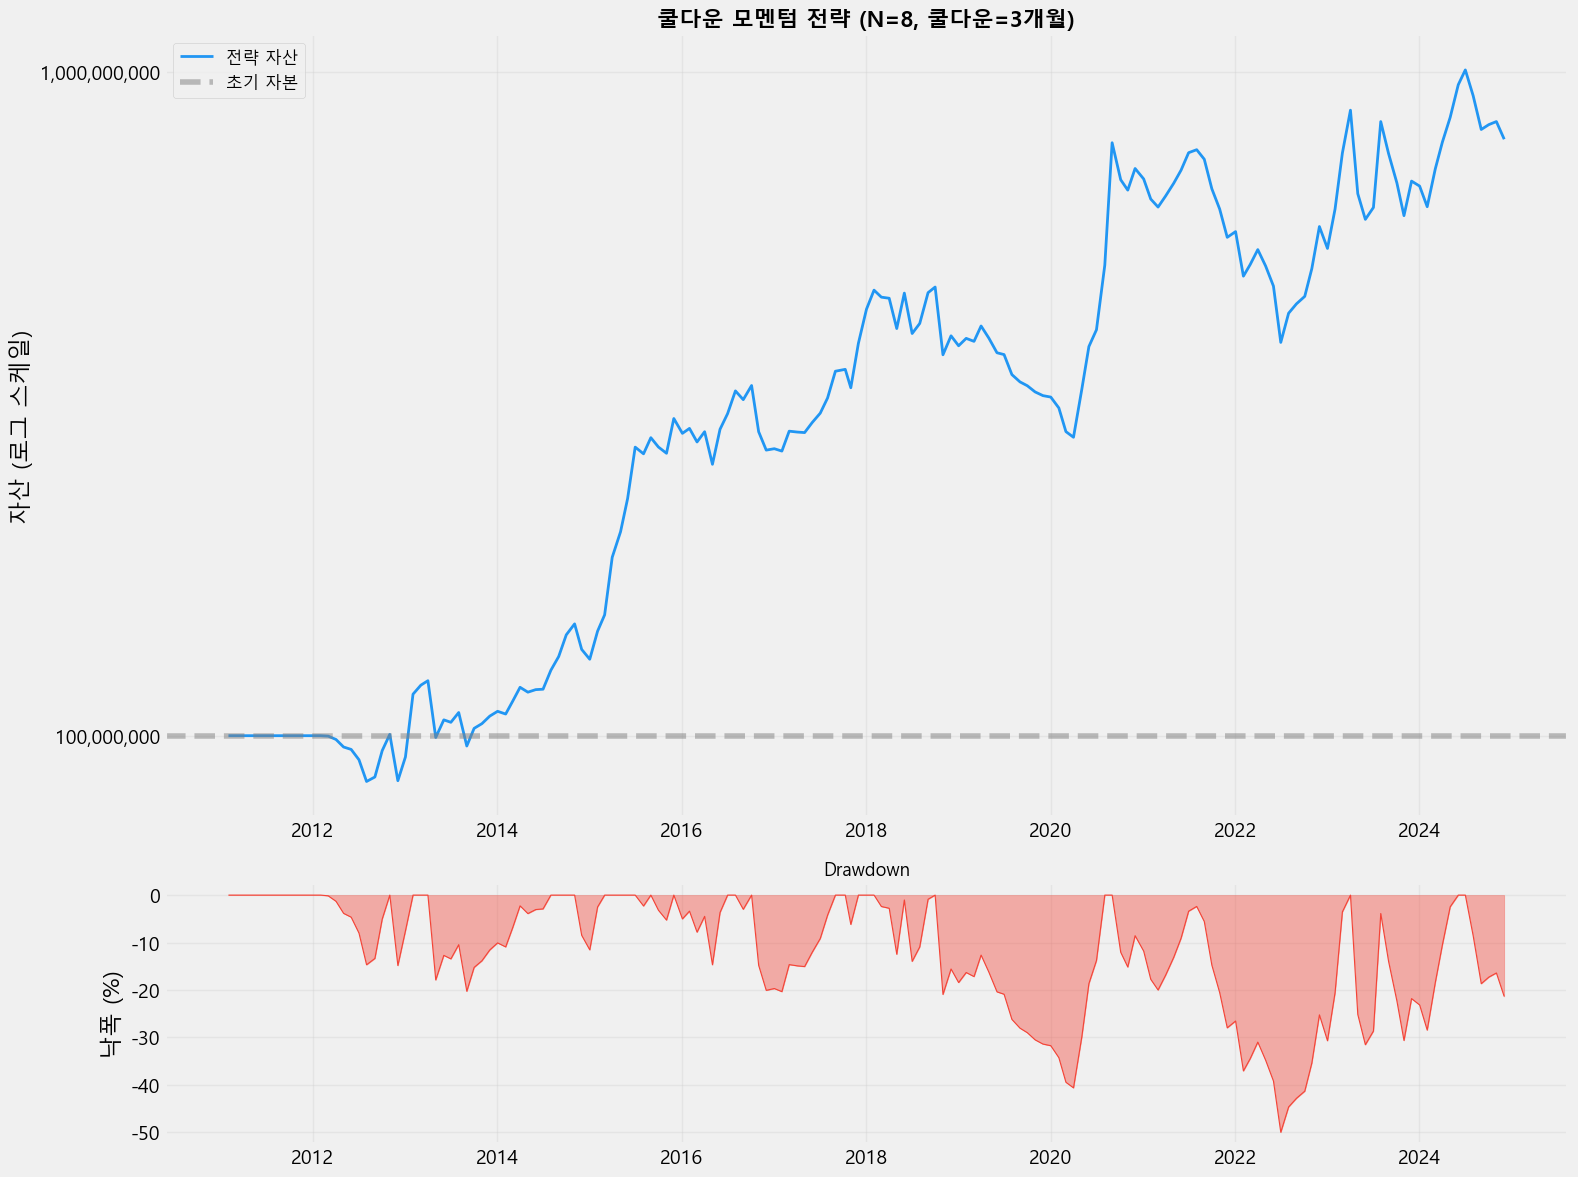

: 

In [ ]:
# ============================================================
# [CELL 12] 시각화
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [3, 1]})

# (1) 자산 곡선 (로그 스케일)
ax1 = axes[0]
ax1.plot(perf_df.index, perf_df["Value"], lw=2, color="#2196F3", label="전략 자산")
ax1.axhline(y=CONFIG["INITIAL_CAPITAL"], color="gray", ls="--", alpha=0.5, label="초기 자본")
ax1.set_yscale("log")
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
ax1.set_title(f"쿨다운 모멘텀 전략 (N={CONFIG['N_MOM']}, 쿨다운={CONFIG['COOLDOWN_MONTHS']}개월)",
              fontsize=16, fontweight="bold")
ax1.set_ylabel("자산 (로그 스케일)")
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# (2) 낙폭 (Drawdown)
ax2 = axes[1]
running_max = perf_df["Value"].cummax()
drawdown = (perf_df["Value"] / running_max - 1) * 100
ax2.fill_between(drawdown.index, drawdown.values, 0, color="#F44336", alpha=0.4)
ax2.plot(drawdown.index, drawdown.values, color="#F44336", lw=0.8)
ax2.set_ylabel("낙폭 (%)")
ax2.set_title("Drawdown", fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 룩어헤드 / 데이터 누수 방지 체크리스트

| # | 항목 | 처리 방식 |
|---|------|----------|
| 1 | **모멘텀 신호 시점** | 월말 리샘플링 후 `shift(1)` 적용 → 전월 말 확정 종가만 사용. 당월 데이터는 신호에 포함되지 않음. |
| 2 | **체결 가격** | 리밸런싱 월 **첫 거래일 종가**로 체결. 신호 생성 시점(전월 말)과 체결 시점이 명확히 분리됨. |
| 3 | **일간 shift vs 월간 shift** | 일간 데이터에서 `shift(21)`은 공휴일·휴장에 따라 정확한 1개월이 아닐 수 있음. 본 코드는 **월별 리샘플링 후 정확한 shift(N)**을 사용. |
| 4 | **종목 유니버스** | CSV로 사전 정의된 종목 사용. 다만 현재 시점의 지수 구성종목을 사용하므로 **생존자 편향(survivorship bias)**이 존재할 수 있음. 과거 시점별 지수 구성종목 데이터가 있으면 교체 가능. |
| 5 | **데이터 부족 종목** | `MIN_HISTORY_DAYS` 미만 데이터 종목은 제외하여, 불완전한 모멘텀 계산 방지. |
| 6 | **미래 가격 참조** | `get_signal_momentum()`은 `rebal_date - 1일` 이전 데이터만 조회. `get_exec_price()`는 리밸런싱 당일 이후 첫 종가만 사용. |